### DS 3026 Final Project - Section 5
# Part 5: Resampling and Simulation

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

<!-- What is the true long-run probability that the home team wins an NBA game? -->

**Parameter of Interest:** π = the true long-run probability that the home team wins an NBA game

**Estimator:** p̂ = (number of home wins) / (total number of games)

NOTE: This section quantifies the variability of p̂ with uncertainty attributed to season-scoped results.

In [1]:
#downloading libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from statsmodels.stats.proportion import proportion_confint
#setting seed
np.random.seed(42)


### Data Prep

In [2]:
game_df = pd.read_csv('game_df.csv')
reg = game_df[game_df['season_type'] == 'Regular Season'].copy()

reg['home_win'] = (reg['wl_home'] == 'W').astype(int)
reg['pt_diff']  = reg['pts_home'] - reg['pts_away']
reg['season_year'] = reg['season_id'].astype(str).str[-4:].astype(int)

#setting n
n = len(reg)
#summing number of wins
n_wins = reg['home_win'].sum()
#calculating p hat
p_hat  = n_wins / n
#getting base stats
outcomes = reg['home_win'].values
pt_diffs = reg['pt_diff'].values
fg_pcts  = reg['fg_pct_home'].values

### Bootstrap: Home-Win Probability

We draw B = 10,000 bootstrap samples (with replacement, same size as original) from the observed win/loss outcomes.

For each, we compute p^hat*. The percentile method gives a 95% CI as the 2.5th and 97.5th percentiles of the bootstrap distribution.

In [3]:
# Bootstrap CI for home-win probability
n_boot = 10000
boot_props = np.zeros(n_boot)
for i in range(n_boot):
    #resample with replacement from original wins/losses
    boot_sample = np.random.choice([1, 0], size=n,
                                    p=[p_hat, 1 - p_hat], replace=True)
    boot_props[i] = boot_sample.mean()

#95% bootstrap CI
boot_lo = np.percentile(boot_props, 2.5)
boot_hi = np.percentile(boot_props, 97.5)
#results
print(f'Bootstrap 95% CI: ({boot_lo:.6f}, {boot_hi:.6f})')

#boot standard error
boot_se = np.std(boot_props)

Bootstrap 95% CI: (0.591714, 0.603867)


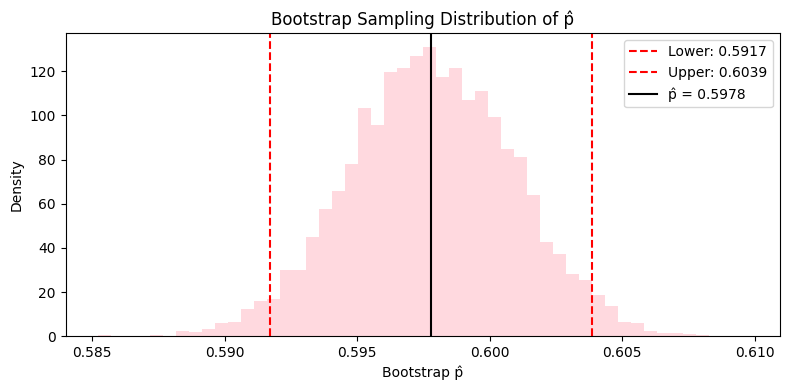

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(boot_props, bins=50, color='pink', alpha=0.6, density=True)
ax.axvline(boot_lo, color='red', ls='--', lw=1.5, label=f'Lower: {boot_lo:.4f}')
ax.axvline(boot_hi, color='red', ls='--', lw=1.5, label=f'Upper: {boot_hi:.4f}')
ax.axvline(p_hat,   color='black', ls='-', lw=1.5, label=f'p̂ = {p_hat:.4f}')

ax.set_xlabel('Bootstrap p̂')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Sampling Distribution of p̂')
ax.legend()
plt.tight_layout()
plt.show()

### Monte Carlo Simulation

**Simulating a Full NBA Season**

An NBA team plays 82 games per season (41 home, 41 away). Given our estimate:
- P(win at home) = p^hat = 0.5993  
- P(win away) around 1 − p^hat = 0.4007

We simulate 10,000 seasons to estimate the distribution of total wins.

In [7]:
#use observed home-win rate
p_home = p_hat
#away win rate is the complement
p_away = 1 - p_hat
#number of simulated seasons and games per season
N_sim = 10_000
home_games = 41
away_games = 41

#simulate home and away wins separately, then combine
sim_home_wins  = np.random.binomial(n=home_games, p=p_home, size=N_sim)
sim_away_wins  = np.random.binomial(n=away_games, p=p_away, size=N_sim)
sim_total_wins = sim_home_wins + sim_away_wins

#summarize simulated seasons
expected_wins = sim_total_wins.mean()
ci_80 = (np.percentile(sim_total_wins, 10), np.percentile(sim_total_wins, 90))
ci_95 = (np.percentile(sim_total_wins, 2.5), np.percentile(sim_total_wins, 97.5))

print(f'Expected wins: {expected_wins:.1f}')
print(f'80% interval:  ({ci_80[0]:.0f}, {ci_80[1]:.0f})')
print(f'95% interval:  ({ci_95[0]:.0f}, {ci_95[1]:.0f})')

#theoretical check using binomial mean/variance formulas
theory_mean= 41*p_home + 41*p_away
theory_sd= np.sqrt(41*p_home*(1-p_home) + 41*p_away*(1-p_away))
#printing results
print(f'Theoretical mean: {theory_mean:.2f}  (simulated: {expected_wins:.2f})')
print(f'Theoretical SD:   {theory_sd:.3f}  (simulated: {sim_total_wins.std():.3f})')

Expected wins: 41.0
80% interval:  (35, 47)
95% interval:  (32, 50)
Theoretical mean: 41.00  (simulated: 40.98)
Theoretical SD:   4.440  (simulated: 4.410)


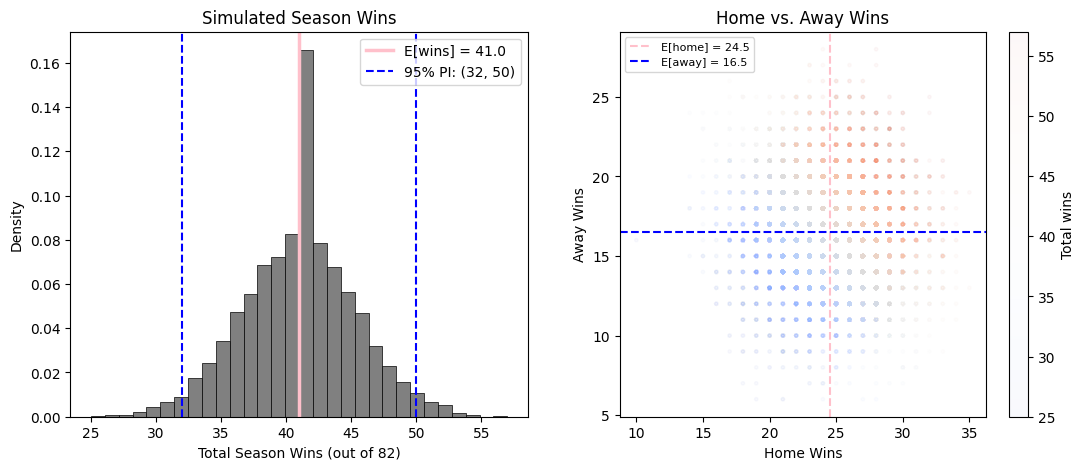

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#season win distribution (left graph)
ax = axes[0]
ax.hist(sim_total_wins, bins=30, color='grey', edgecolor='black', linewidth=0.5, density=True)
ax.axvline(expected_wins, color='pink', lw=2.5, label=f'E[wins] = {expected_wins:.1f}')
ax.axvline(ci_95[0], color='blue', lw=1.5, ls='--', label=f'95% PI: ({ci_95[0]:.0f}, {ci_95[1]:.0f})')
ax.axvline(ci_95[1], color='blue', lw=1.5, ls='--')
ax.set_xlabel('Total Season Wins (out of 82)')
ax.set_ylabel('Density')
ax.set_title('Simulated Season Wins')
ax.legend()
#home vs away wins (right graph)
ax2 = axes[1]
scatter = ax2.scatter(sim_home_wins, sim_away_wins, alpha=0.03, s=6, c=sim_total_wins, cmap='coolwarm')
plt.colorbar(scatter, ax=ax2, label='Total wins')
ax2.axvline(41*p_home, color='pink', lw=1.5, ls='--', label=f'E[home] = {41*p_home:.1f}')
ax2.axhline(41*p_away, color='blue', lw=1.5, ls='--', label=f'E[away] = {41*p_away:.1f}')
ax2.set_xlabel('Home Wins')
ax2.set_ylabel('Away Wins')
ax2.set_title('Home vs. Away Wins')
ax2.legend(fontsize=8)

#plotting
plt.show()

### Monte Carlo (cont)
**Simulating the Effect of Losing Home-Court Advantage**

We use Monte Carlo to answer: How many wins would an average team lose if home-court advantage were eliminated?

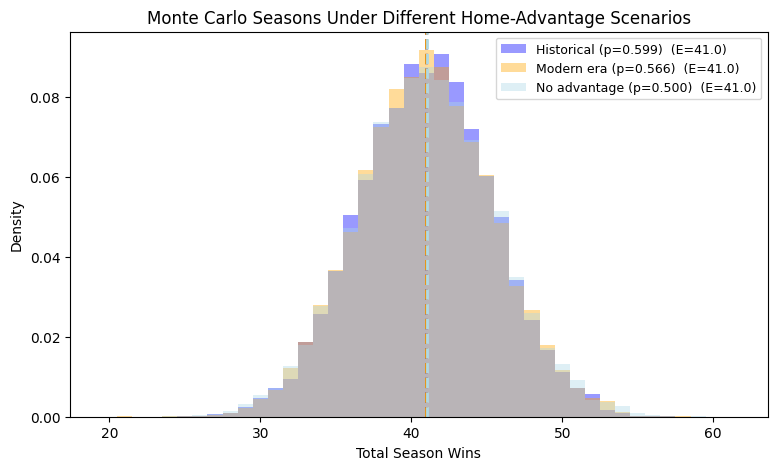

In [16]:
#season win distribution (no home advantage)
# during the 2020 NBA bubble, games were played at a neutral site
# so we model both home and away win probability as 0.5
p_bubble = 0.5
sim_wins_bubble = np.random.binomial(82, p_bubble, size=N_sim)

#Modern
#recent seasons show a weaker home advantage (~56.6% home win rate)
p_modern = 0.566
#home games
sim_home_mod = np.random.binomial(41, p_modern, size=N_sim)
#away agmes (complement)
sim_away_mod = np.random.binomial(41, 1 - p_modern, size=N_sim)
#total wins
sim_wins_mod = sim_home_mod + sim_away_mod

#plot all three cases
# Historical: uses sim_total_wins computed earlier with p_hat
scenarios = {
    #observed p^hat
    'Historical (p=0.599)':sim_total_wins,
    #weaker home effect
    'Modern era (p=0.566)':sim_wins_mod,
    #nuetral game site
    'No advantage (p=0.500)':  sim_wins_bubble
}

#plotting overhapping histograms
fig, ax = plt.subplots(figsize=(9, 5))
palette = ['blue', 'orange', 'lightblue']

for (label, sims), color in zip(scenarios.items(), palette):
    # plot density histogram so all three are on the same scale
    ax.hist(sims, bins=np.arange(19.5, 62.5), density=True,
            alpha=0.4, color=color, label=f'{label}  (E={sims.mean():.1f})')
    # dashed vertical line at the mean for each scenario
    ax.axvline(sims.mean(), color=color, lw=2, ls='--')

ax.set_xlabel('Total Season Wins')
ax.set_ylabel('Density')
ax.set_title('Monte Carlo Seasons Under Different Home-Advantage Scenarios')
ax.legend(fontsize=9)
plt.show()

## 5. Estimator Variability Comparison

We compare bootstrap SE to theoretical SE across all statistics estimated in this project. The ratio boot_SE / theory_SE should be around 1.0 if the CLT approximation holds, and will deviate for statistics without simple asymptotic formulas (like the median).

In [17]:
# bootstrap SE for point differential
boot_diff = np.zeros(n_boot)
for i in range(n_boot):
    boot_sample = np.random.choice(pt_diffs, size=len(pt_diffs), replace=True)
    boot_diff[i] = boot_sample.mean()
se_diff = np.std(boot_diff)

# bootstrap SE for median
boot_med = np.zeros(n_boot)
for i in range(n_boot):
    boot_sample = np.random.choice(pt_diffs, size=len(pt_diffs), replace=True)
    boot_med[i] = np.median(boot_sample)

# bootstrap SE for FG%
boot_fg = np.zeros(n_boot)
for i in range(n_boot):
    boot_sample = np.random.choice(fg_pcts, size=len(fg_pcts), replace=True)
    boot_fg[i] = boot_sample.mean()
se_fg = np.std(boot_fg)

In [18]:
# Collect all SE comparisons
theory_se_prop = np.sqrt(p_hat * (1 - p_hat) / n)
theory_se_diff_mean = np.std(pt_diffs) / np.sqrt(n)
theory_se_fg_mean   = np.std(fg_pcts) / np.sqrt(n)

# Theoretical SE for median ≈ 1/(2*f(m)*sqrt(n)) where f is density at median
from scipy.stats import gaussian_kde
kde = gaussian_kde(pt_diffs)
med_obs = np.median(pt_diffs)
theory_se_med = 1 / (2 * kde(med_obs)[0] * np.sqrt(n))

summary = pd.DataFrame({
    'Statistic':['Home-Win Prob (p̂)', 'Mean Pt Diff', 'Median Pt Diff', 'Mean FG%'],
    'Observed':[p_hat, pt_diffs.mean(), med_obs, fg_pcts.mean()],
    'Bootstrap SE':[boot_se, se_diff, np.std(boot_med), se_fg],
    'Theoretical SE':[theory_se_prop, theory_se_diff_mean, theory_se_med[0] if hasattr(theory_se_med,'__len__') else theory_se_med, theory_se_fg_mean],
})
summary['Ratio (B/T)'] = (summary['Bootstrap SE'] / summary['Theoretical SE']).round(4)
summary[['Observed','Bootstrap SE','Theoretical SE']] = summary[['Observed','Bootstrap SE','Theoretical SE']].round(6)
print(summary.to_string(index=False))

         Statistic  Observed  Bootstrap SE  Theoretical SE  Ratio (B/T)
Home-Win Prob (p̂)  0.597771      0.003096        0.003055       1.0133
      Mean Pt Diff  3.128601      0.085316        0.086005       0.9920
    Median Pt Diff  5.000000      0.036032        0.095687       0.3766
          Mean FG%  0.461654      0.000357        0.000359       0.9932


Ratios close to 1.0 confirm the CLT approximation is valid for these statistics.
The median ratio may deviate slightly because its theoretical SE relies on KDE.

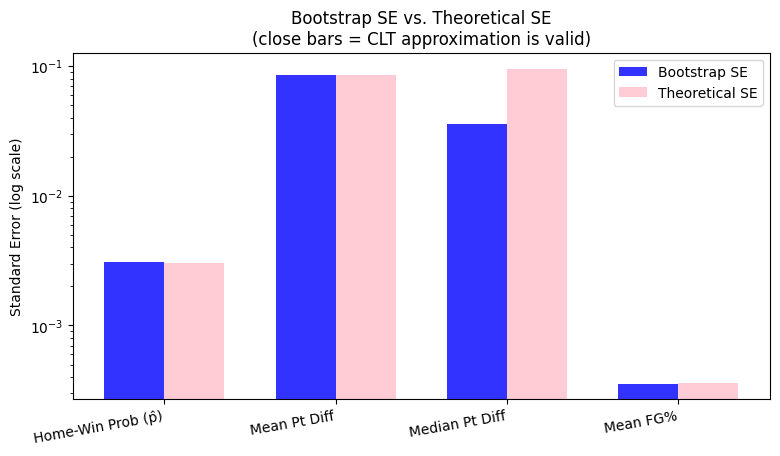

In [19]:
# Visual: Bootstrap SE vs Theoretical SE bar chart
fig, ax = plt.subplots(figsize=(9, 4.5))
stats_labels = summary['Statistic'].tolist()
x = np.arange(len(stats_labels))
width = 0.35
#creating the bar graphs to compare the se of boostrap and theortical
bars1 = ax.bar(x - width/2, summary['Bootstrap SE'],   width, label='Bootstrap SE',    color='blue',   alpha=0.8)
bars2 = ax.bar(x + width/2, summary['Theoretical SE'], width, label='Theoretical SE',  color='pink', alpha=0.8)
#setting x labels and ticks
ax.set_xticks(x)
ax.set_xticklabels(stats_labels, rotation=10, ha='right')
ax.set_ylabel('Standard Error')
ax.set_title('Bootstrap SE vs. Theoretical SE\n(close bars = CLT approximation is valid)')
ax.legend()
#log scale because SEs span different orders of magnitude
ax.set_yscale('log')
ax.set_ylabel('Standard Error (log scale)')
plt.show()